# Klasifikasi Emosi Review Produk Tokopedia dengan IndoBERT
**Mata Kuliah:** Text Mining  
**Dataset:** PRDECT-ID

**Model:** `indobenchmark/indobert-base-p1`

---
### Pipeline
```
Load Data → EDA → Preprocessing → Tokenisasi → Fine-tuning IndoBERT → Evaluasi → Prediksi
```

## 1. Install Library

In [ ]:
!pip install transformers datasets evaluate accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/84.1 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00


## 2. Import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)

# Konstanta
TEXT_COL  = "Customer Review"
LABEL_COL = "Emotion"
MODEL_ID  = "indobenchmark/indobert-base-p1"
MAX_LEN   = 128
SEED      = 42

# Emotion Colors
EMOTION_COLORS = {
    "Happy":   "#2ecc71",
    "Sadness": "#3498db",
    "Fear":    "#9b59b6",
    "Love":    "#e74c3c",
    "Anger":   "#e67e22",
}

## 3. Load Dataset

In [ ]:
df_raw = pd.read_csv("/content/PRDECT-ID Dataset.csv")

print(f"Shape  : {df_raw.shape}")
print(f"Kolom  : {df_raw.columns.tolist()}")
df_raw.head(3)

Shape  : (5400, 11)
Kolom  : ['Category', 'Product Name', 'Location', 'Price', 'Overall Rating', 'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review', 'Sentiment', 'Emotion']


,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",Positive,Happy
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",Positive,Happy


## 4. Exploratory Data Analysis (EDA)

### 4.1 Info & Missing Values

In [ ]:
print("=== DataFrame Info ===")
df_raw.info()
print()
print("=== Missing Values ===")
print(df_raw.isnull().sum())
print()
print("=== Duplikat ===")
print(f"Jumlah baris duplikat: {df_raw.duplicated().sum()}")

=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5400 entries, 0 to 5399
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Category         5400 non-null   object 
 1   Product Name     5400 non-null   object 
 2   Location         5400 non-null   object 
 3   Price            5400 non-null   int64  
 4   Overall Rating   5400 non-null   float64
 5   Number Sold      5400 non-null   int64  
 6   Total Review     5400 non-null   int64  
 7   Customer Rating  5400 non-null   int64  
 8   Customer Review  5400 non-null   object 
 9   Sentiment        5400 non-null   object 
 10  Emotion          5400 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 464.2+ KB

=== Missing Values ===
Category           0
Product Name       0
Location           0
Price              0
Overall Rating     0
Number Sold        0
Total Review       0
Customer Rating    0
Customer Review 

### 4.2 Distribusi Kelas Emosi

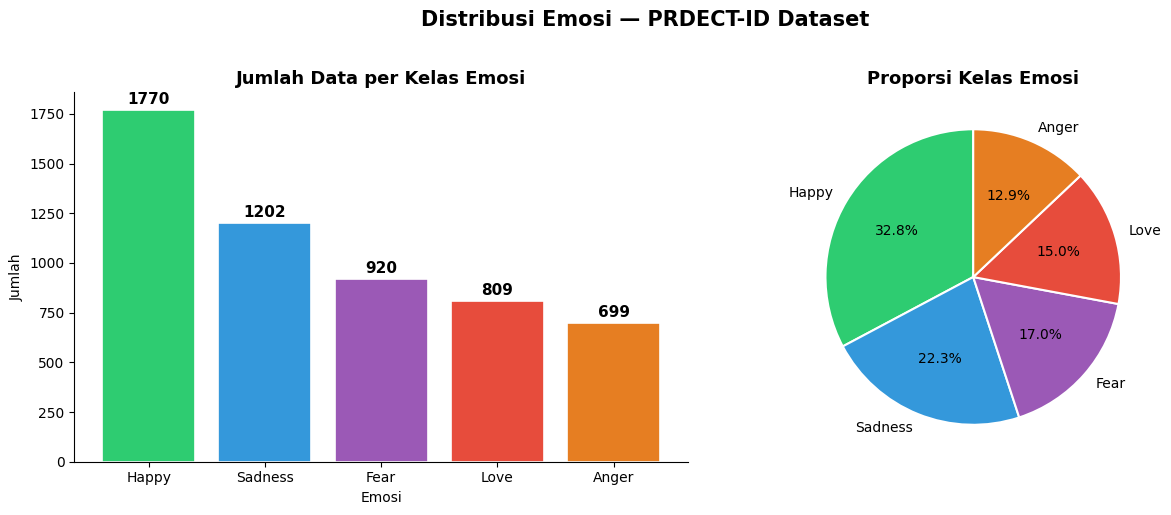


=== Ringkasan Distribusi ===
         Jumlah  Persentase (%)
Emotion                        
Happy      1770           32.78
Sadness    1202           22.26
Fear        920           17.04
Love        809           14.98
Anger       699           12.94


In [ ]:
emotion_counts = df_raw[LABEL_COL].value_counts()
colors = [EMOTION_COLORS[e] for e in emotion_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
axes[0].bar(emotion_counts.index, emotion_counts.values, color=colors, edgecolor="white", linewidth=1.2)
for i, (label, val) in enumerate(zip(emotion_counts.index, emotion_counts.values)):
    axes[0].text(i, val + 15, str(val), ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[0].set_title("Jumlah Data per Kelas Emosi", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Emosi")
axes[0].set_ylabel("Jumlah")
axes[0].spines[["top", "right"]].set_visible(False)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    emotion_counts.values, labels=emotion_counts.index,
    colors=colors, autopct="%1.1f%%", startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
for at in autotexts:
    at.set_fontsize(10)
axes[1].set_title("Proporsi Kelas Emosi", fontsize=13, fontweight="bold")

plt.suptitle("Distribusi Emosi — PRDECT-ID Dataset", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\n=== Ringkasan Distribusi ===")
summary = pd.DataFrame({
    "Jumlah": emotion_counts,
    "Persentase (%)": (emotion_counts / len(df_raw) * 100).round(2),
})
print(summary)

### 4.3 Distribusi Sentimen

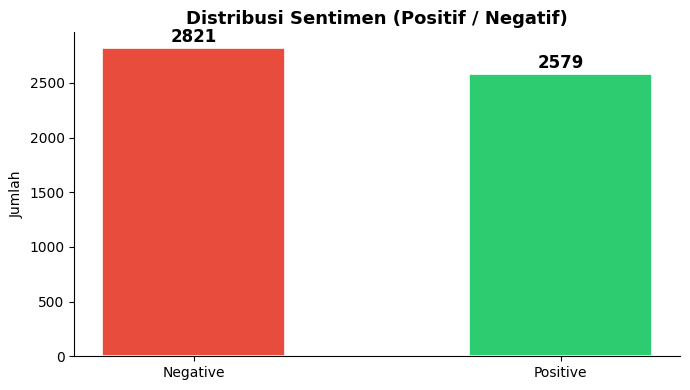

In [ ]:
sentiment_counts = df_raw["Sentiment"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(sentiment_counts.index, sentiment_counts.values,
              color=["#e74c3c", "#2ecc71"], edgecolor="white", linewidth=1.2, width=0.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            str(bar.get_height()), ha="center", va="bottom", fontsize=12, fontweight="bold")
ax.set_title("Distribusi Sentimen (Positif / Negatif)", fontsize=13, fontweight="bold")
ax.set_ylabel("Jumlah")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 4.4 Top-15 Kategori Produk

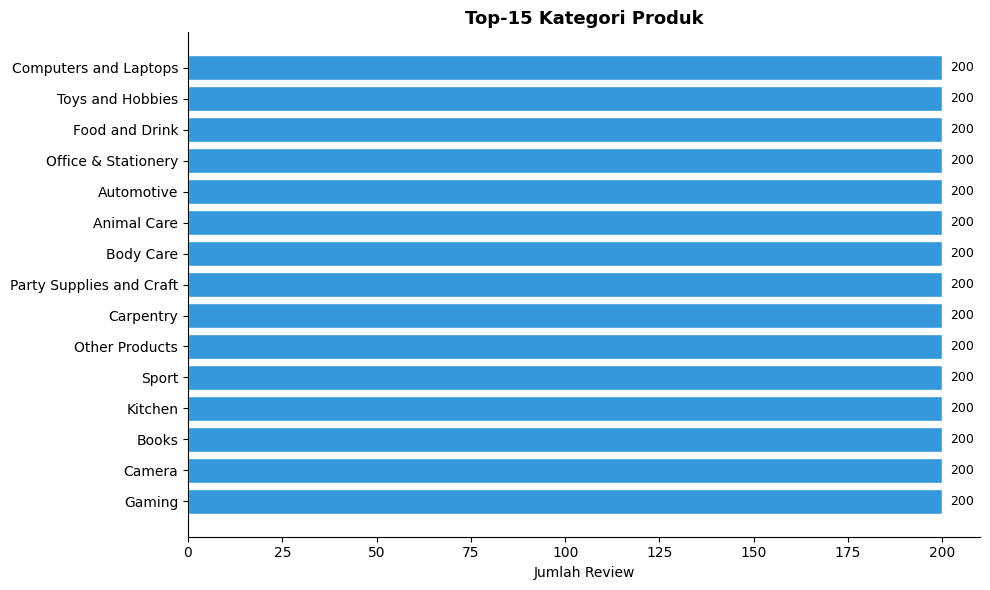

In [ ]:
cat_counts = df_raw["Category"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(cat_counts.index[::-1], cat_counts.values[::-1], color="#3498db", edgecolor="white")
for bar in bars:
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
            str(int(bar.get_width())), va="center", fontsize=9)
ax.set_title("Top-15 Kategori Produk", fontsize=13, fontweight="bold")
ax.set_xlabel("Jumlah Review")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 4.5 Hubungan Emosi & Sentimen

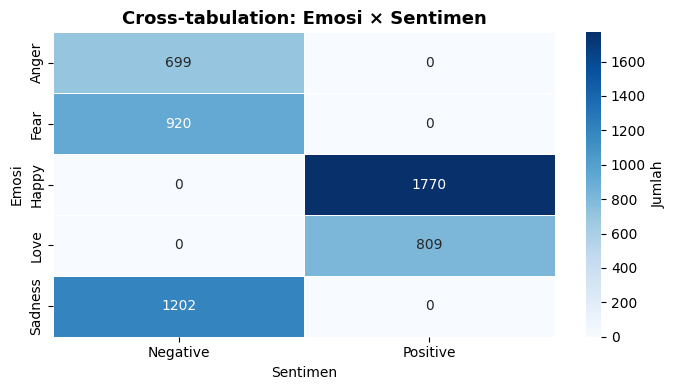

In [ ]:
ct = pd.crosstab(df_raw[LABEL_COL], df_raw["Sentiment"])

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", linewidths=0.5,
            cbar_kws={"label": "Jumlah"}, ax=ax)
ax.set_title("Cross-tabulation: Emosi × Sentimen", fontsize=13, fontweight="bold")
ax.set_xlabel("Sentimen")
ax.set_ylabel("Emosi")
plt.tight_layout()
plt.show()

### 4.6 Distribusi Panjang Teks Review

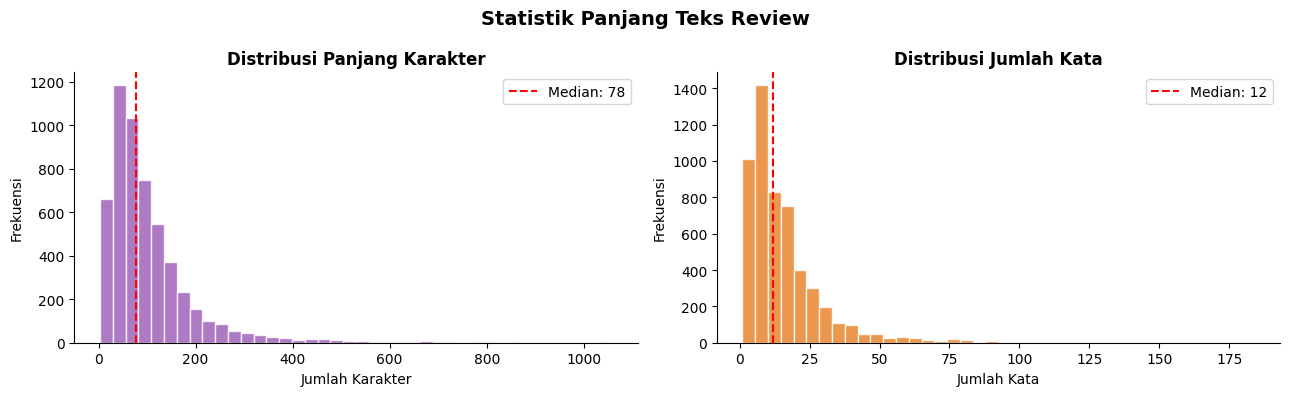


=== Statistik Deskriptif Panjang Teks ===
       text_len  word_count
count    5400.0      5400.0
mean      103.8        16.1
std        98.3        15.6
min         3.0         1.0
25%        44.0         7.0
50%        78.0        12.0
75%       128.0        20.0
max      1058.0       184.0


In [ ]:
df_raw["text_len"] = df_raw[TEXT_COL].astype(str).apply(len)
df_raw["word_count"] = df_raw[TEXT_COL].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Karakter
axes[0].hist(df_raw["text_len"], bins=40, color="#9b59b6", edgecolor="white", alpha=0.8)
axes[0].axvline(df_raw["text_len"].median(), color="red", linestyle="--", linewidth=1.5,
                label=f"Median: {df_raw['text_len'].median():.0f}")
axes[0].set_title("Distribusi Panjang Karakter", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Jumlah Karakter")
axes[0].set_ylabel("Frekuensi")
axes[0].legend()
axes[0].spines[["top", "right"]].set_visible(False)

# Kata
axes[1].hist(df_raw["word_count"], bins=40, color="#e67e22", edgecolor="white", alpha=0.8)
axes[1].axvline(df_raw["word_count"].median(), color="red", linestyle="--", linewidth=1.5,
                label=f"Median: {df_raw['word_count'].median():.0f}")
axes[1].set_title("Distribusi Jumlah Kata", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Jumlah Kata")
axes[1].set_ylabel("Frekuensi")
axes[1].legend()
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("Statistik Panjang Teks Review", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n=== Statistik Deskriptif Panjang Teks ===")
print(df_raw[["text_len", "word_count"]].describe().round(1))

### 4.7 Panjang Teks per Kelas Emosi

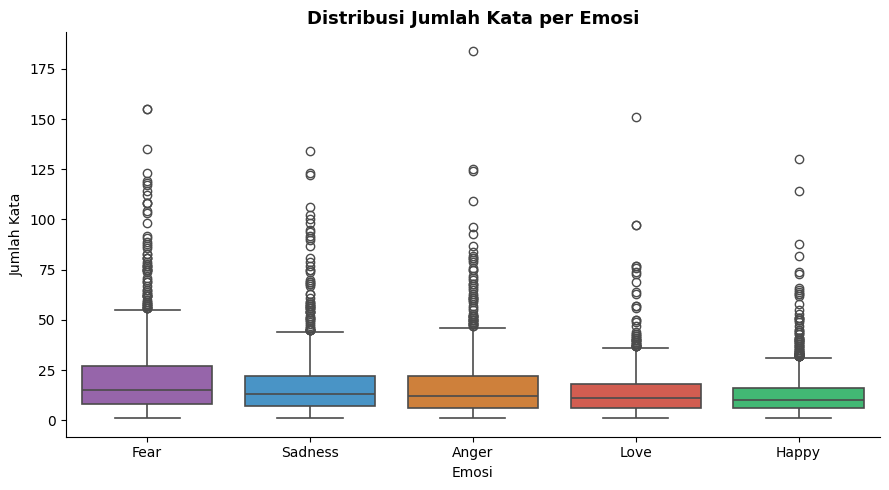

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
order = df_raw.groupby(LABEL_COL)["word_count"].median().sort_values(ascending=False).index
palette = {e: EMOTION_COLORS[e] for e in order}
sns.boxplot(data=df_raw, x=LABEL_COL, y="word_count", order=order,
            palette=palette, linewidth=1.2, ax=ax)
ax.set_title("Distribusi Jumlah Kata per Emosi", fontsize=13, fontweight="bold")
ax.set_xlabel("Emosi")
ax.set_ylabel("Jumlah Kata")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 4.8 Contoh Review per Emosi

In [ ]:
print("=== Contoh Review per Emosi ===\n")
for emotion in df_raw[LABEL_COL].unique():
    sample = df_raw[df_raw[LABEL_COL] == emotion][TEXT_COL].sample(1, random_state=SEED).values[0]
    print(f"[{emotion:8s}] {sample[:120]}...")
    print()

=== Contoh Review per Emosi ===

[Happy   ] Barang sudah di trima dgn baik dan rapi, suara nya oke... Thanks...

[Sadness ] Produk yang saya terima kondisi motor sabliziernya kurang baik, al hasil video bukannya jadi mulus malah unstableized...

[Anger   ] pihak toko tidak jelas, di minta barang a yg datang barang b, dan pihak toko merasa benar, ada barang yg ga di kirim pen...

[Love    ] mantap hijabnyaaa, enaaaaaak dipakai, adeeeeem...

[Fear    ] order pake kardus ternyata dikirim pake plastik doang...



## 5. Preprocessing

In [ ]:
# Ambil kolom yang dibutuhkan, buang missing
df = df_raw[[TEXT_COL, LABEL_COL]].dropna().reset_index(drop=True)

def clean_text(text: str) -> str:
    return str(text).lower().strip()

df[TEXT_COL] = df[TEXT_COL].apply(clean_text)

print(f"Jumlah data setelah cleaning : {len(df)}")
df.head(3)

Jumlah data setelah cleaning : 5400


,Customer Review,Emotion
0,alhamdulillah berfungsi dengan baik. packaging...,Happy
1,"barang bagus dan respon cepat, harga bersaing ...",Happy
2,"barang bagus, berfungsi dengan baik, seler ram...",Happy


## 6. Encode Label

In [ ]:
encoder = LabelEncoder()
df["label"] = encoder.fit_transform(df[LABEL_COL])

print("Label Mapping:")
for idx, label in enumerate(encoder.classes_):
    print(f"  {idx} → {label}")

Label Mapping:
  0 → Anger
  1 → Fear
  2 → Happy
  3 → Love
  4 → Sadness


## 7. Train-Test Split

In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df["label"],
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train : {len(train_df):,} data")
print(f"Test  : {len(test_df):,} data")

train_ds = Dataset.from_pandas(train_df)
test_ds  = Dataset.from_pandas(test_df)

Train : 4,320 data
Test  : 1,080 data


## 8. Tokenisasi IndoBERT

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

def tokenize(batch):
    return tokenizer(
        batch[TEXT_COL],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
    )

train_ds = train_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

print("Tokenisasi selesai")
print(f"Fitur dataset: {train_ds.column_names}")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/4320 [00:00<?, ? examples/s]

Map:   0%|          | 0/1080 [00:00<?, ? examples/s]

Tokenisasi selesai
Fitur dataset: ['Customer Review', 'Emotion', 'label', 'input_ids', 'token_type_ids', 'attention_mask']


## 9. Load Model IndoBERT

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID,
    num_labels=len(encoder.classes_),
)
print(f"Model dimuat | Parameter: {model.num_parameters():,}")

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model dimuat | Parameter: 124,445,189


## 10. Fungsi Metrik Evaluasi

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro"
    )
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

## Class Weights

In [ ]:
training_args = TrainingArguments(
    output_dir="hasil",
    num_train_epochs=3,        # ← dari 5 turunkan ke 3
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    report_to="none",
)

In [ ]:
import numpy as np
import torch
from sklearn.utils.class_weight import compute_class_weight

train_labels = np.array(train_ds['label'])

unique_classes = np.unique(train_labels)
weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=train_labels
)

print("Bobot otomatis:", weights)

# ✅ Tambahkan ini — override manual
weights_manual = np.array([1.5, 1.5, 1.0, 3.0, 1.5])
class_weights_tensor = torch.tensor(weights_manual, dtype=torch.float)
print("Bobot manual:", weights_manual)

Bobot otomatis: [1.54561717 1.17391304 0.61016949 1.33539413 0.8981289 ]
Bobot manual: [1.5 1.5 1.  3.  1.5]


In [ ]:
# custom trainer
import torch.nn as nn
from transformers import Trainer

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")

        outputs = model(**inputs)
        logits = outputs.get("logits")
        device = model.device

        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

## 11. Fine-Tuning

In [ ]:
training_args = TrainingArguments(
    output_dir="hasil",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    report_to="none",
)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.726341,0.686855,0.687037,0.662566,0.664477,0.655156
2,0.634093,0.734853,0.680556,0.654440,0.678612,0.647922
3,0.398002,0.747844,0.702778,0.676306,0.680281,0.674056
4,0.231088,0.902468,0.692593,0.665720,0.666190,0.662407
5,0.139008,1.063075,0.700000,0.673144,0.665906,0.666127


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1350, training_loss=0.43656768233687787, metrics={'train_runtime': 654.5844, 'train_samples_per_second': 32.998, 'train_steps_per_second': 2.062, 'total_flos': 1420837969305600.0, 'train_loss': 0.43656768233687787, 'epoch': 5.0})

In [ ]:
import json
from pathlib import Path

SAVE_DIR = Path("model_indobert_emosi")
SAVE_DIR.mkdir(exist_ok=True)

trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

with open(SAVE_DIR / "labels.json", "w", encoding="utf-8") as f:
    json.dump(encoder.classes_.tolist(), f, ensure_ascii=False, indent=2)

print(f"Model, tokenizer, dan labels disimpan ke folder: {SAVE_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model, tokenizer, dan labels disimpan ke folder: model_indobert_emosi


## 12. Evaluasi Model

### 12.1 Classification Report

In [ ]:
pred_output = trainer.predict(test_ds)
y_pred = pred_output.predictions.argmax(axis=1)
y_true = pred_output.label_ids

print(classification_report(y_true, y_pred, target_names=encoder.classes_))

              precision    recall  f1-score   support

       Anger       0.62      0.49      0.55       140
        Fear       0.50      0.58      0.54       184
       Happy       0.90      0.80      0.85       354
        Love       0.69      0.86      0.77       162
     Sadness       0.66      0.68      0.67       240

    accuracy                           0.70      1080
   macro avg       0.68      0.68      0.67      1080
weighted avg       0.71      0.70      0.70      1080



### 12.2 Confusion Matrix

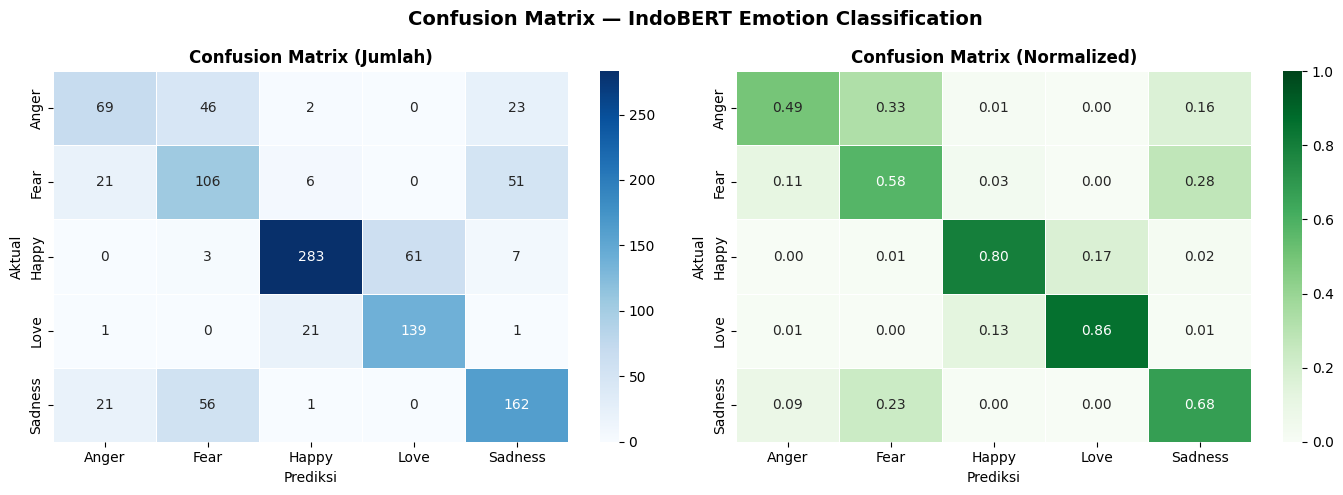

In [ ]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=encoder.classes_, yticklabels=encoder.classes_,
            linewidths=0.5, ax=axes[0])
axes[0].set_title("Confusion Matrix (Jumlah)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Prediksi")
axes[0].set_ylabel("Aktual")

# Normalized
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=encoder.classes_, yticklabels=encoder.classes_,
            linewidths=0.5, vmin=0, vmax=1, ax=axes[1])
axes[1].set_title("Confusion Matrix (Normalized)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Prediksi")
axes[1].set_ylabel("Aktual")

plt.suptitle("Confusion Matrix — IndoBERT Emotion Classification", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 12.3 Ringkasan Metrik

                    Nilai
Metrik                   
Accuracy           0.7028
Precision (macro)  0.6763
Recall (macro)     0.6803
F1-Score (macro)   0.6741


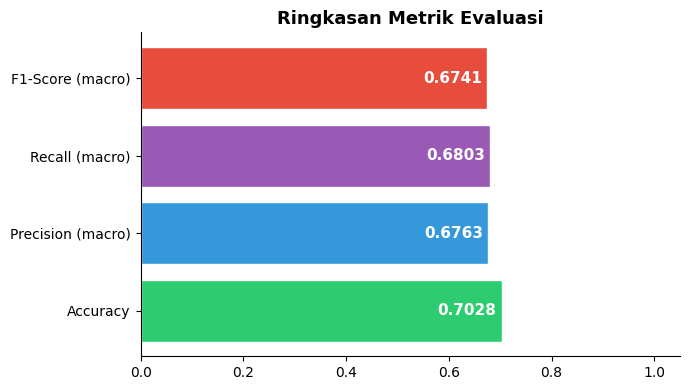

In [ ]:
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")
acc = accuracy_score(y_true, y_pred)

metrics_df = pd.DataFrame({
    "Metrik": ["Accuracy", "Precision (macro)", "Recall (macro)", "F1-Score (macro)"],
    "Nilai": [acc, precision, recall, f1],
}).set_index("Metrik")

print(metrics_df.applymap(lambda x: f"{x:.4f}"))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(metrics_df.index, metrics_df["Nilai"],
               color=["#2ecc71", "#3498db", "#9b59b6", "#e74c3c"],
               edgecolor="white")
for bar in bars:
    ax.text(bar.get_width() - 0.01, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.4f}", va="center", ha="right",
            color="white", fontsize=11, fontweight="bold")
ax.set_xlim(0, 1.05)
ax.set_title("Ringkasan Metrik Evaluasi", fontsize=13, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()